# Stitching Result Viewer

Load `stitching_result.npz`, report the recovered height profile, with-twist and no-twist second-order fits, recovered systematic error, and reconstruction residual statistics. The notebook is backward-compatible with older NPZ files that only contain the legacy `baseline_*` and `adp_*` keys.

In [60]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True

# Change this path to your stitching output folder.
RESULT_DIR = Path(r"D:/exp_data/干涉仪数据-2026/CM2测量原始数据/CM2测量原始数据/M260611-move10mm/stitching_removeTilt_cali_polyLegendre")
NPZ_PATH = RESULT_DIR / "stitching_result.npz"
SUMMARY_PATH = RESULT_DIR / "summary.json"
RUN_PARAMETERS_PATH = RESULT_DIR / "run_parameters.json"

npz = np.load(NPZ_PATH, allow_pickle=True)
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8')) if SUMMARY_PATH.exists() else {}
run_parameters = json.loads(RUN_PARAMETERS_PATH.read_text(encoding='utf-8')) if RUN_PARAMETERS_PATH.exists() else {}
print(f"Loaded NPZ: {NPZ_PATH}")
print(f"Array count: {len(npz.files)}")
if run_parameters:
    print(f"Run status: {run_parameters.get('status', 'unknown')}")
    print(f"Mode: {run_parameters.get('parameters', {}).get('mode', 'unknown')}")

Loaded NPZ: D:\exp_data\干涉仪数据-2026\CM2测量原始数据\CM2测量原始数据\M260611-move10mm\stitching_removeTilt_cali_polyLegendre\stitching_result.npz
Array count: 328
Run status: completed
Mode: both


In [61]:
COEFF_NAMES = np.array(['c', 'bx', 'by', 'qxx', 'qxy', 'qyy'], dtype=object)

def arr(name, default=None):
    return npz[name] if name in npz.files else default

def first_existing(*names):
    for name in names:
        if name in npz.files:
            return name, npz[name]
    return None, None

def scalar_value(a):
    if a is None:
        return np.nan
    a = np.asarray(a)
    return float(a.reshape(-1)[0]) if a.size else np.nan

def finite_rms(a):
    if a is None:
        return np.nan
    a = np.asarray(a, dtype=float)
    v = a[np.isfinite(a)]
    return float(np.sqrt(np.mean(v*v))) if v.size else np.nan

def finite_pv(a):
    if a is None:
        return np.nan
    a = np.asarray(a, dtype=float)
    v = a[np.isfinite(a)]
    return float(np.max(v) - np.min(v)) if v.size else np.nan

def nanmedian_profile(a, axis):
    a = np.asarray(a, dtype=float)
    valid = np.isfinite(a)
    out = np.full(a.shape[1-axis], np.nan, dtype=float)
    for i in range(out.size):
        line = a[:, i] if axis == 0 else a[i, :]
        vals = line[np.isfinite(line)]
        if vals.size:
            out[i] = np.nanmedian(vals)
    return out

def linecut_profile(a, v, axis):
    a = np.asarray(a, dtype=float)
    return a[:, v] if axis == 0 else a[v, :]

def fallback_axes(prefix, raw):
    x_name, x = first_existing(f'{prefix}_profile_x_mm', f'{prefix}_with_twist_profile_x_mm', f'{prefix}_no_twist_profile_x_mm')
    y_name, y = first_existing(f'{prefix}_profile_y_mm', f'{prefix}_with_twist_profile_y_mm', f'{prefix}_no_twist_profile_y_mm')
    if x is None or len(x) != raw.shape[1]:
        x = np.arange(raw.shape[1], dtype=float) - (raw.shape[1] - 1) / 2
    if y is None or len(y) != raw.shape[0]:
        y = np.arange(raw.shape[0], dtype=float) - (raw.shape[0] - 1) / 2
    return np.asarray(y, dtype=float), np.asarray(x, dtype=float)

def radius_from_q(q):
    q = float(q)
    return 500.0 / q if np.isfinite(q) and abs(q) > 1e-15 else np.nan

def fit_second_order_map(raw, mask=None, x_mm=None, y_mm=None, include_twist=True):
    raw = np.asarray(raw, dtype=float)
    if y_mm is None or x_mm is None:
        y_mm, x_mm = fallback_axes('', raw)
    yy, xx = np.meshgrid(np.asarray(y_mm, dtype=float), np.asarray(x_mm, dtype=float), indexing='ij')
    valid = np.isfinite(raw)
    if mask is not None:
        valid &= np.isfinite(mask) & (mask > 0)
    if include_twist:
        cols = [np.ones_like(xx), xx, yy, xx**2, xx*yy, yy**2]
        coeff = np.zeros(6, dtype=float)
        coeff[:] = np.linalg.lstsq(np.stack([c[valid] for c in cols], axis=1), raw[valid], rcond=None)[0]
    else:
        cols = [np.ones_like(xx), xx, yy, xx**2, yy**2]
        small = np.linalg.lstsq(np.stack([c[valid] for c in cols], axis=1), raw[valid], rcond=None)[0]
        coeff = np.array([small[0], small[1], small[2], small[3], 0.0, small[4]], dtype=float)
    fit = coeff[0] + coeff[1]*xx + coeff[2]*yy + coeff[3]*xx**2 + coeff[4]*xx*yy + coeff[5]*yy**2
    residual = raw - fit
    residual[~valid] = np.nan
    fit[~valid] = np.nan
    quad = np.array([[coeff[3], 0.5*coeff[4]], [0.5*coeff[4], coeff[5]]], dtype=float)
    eigvals, eigvecs = np.linalg.eigh(quad)
    order = np.argsort(np.abs(eigvals))[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    principal_radius = np.array([radius_from_q(q) for q in eigvals], dtype=float)
    angles = np.degrees(np.arctan2(eigvecs[1, :], eigvecs[0, :]))
    return {
        'raw': raw,
        'fit': fit,
        'residual': residual,
        'coeff': coeff,
        'coeff_names': COEFF_NAMES,
        'radius': np.array([radius_from_q(coeff[3]), radius_from_q(coeff[5])], dtype=float),
        'principal_q': eigvals,
        'principal_radius': principal_radius,
        'principal_axis_angles_deg': angles,
        'quadratic_matrix': quad,
        'source': 'recomputed from raw height in notebook',
        'x_mm': np.asarray(x_mm, dtype=float),
        'y_mm': np.asarray(y_mm, dtype=float),
    }

def load_fit(base_prefix, mode):
    # mode is 'with_twist' or 'no_twist'. Legacy base_prefix keys are with-twist aliases.
    explicit = f'{base_prefix}_{mode}'
    raw_name, raw = first_existing(f'{explicit}_raw_height_nm', f'{base_prefix}_raw_height_nm')
    fit_name, fit = first_existing(f'{explicit}_second_order_fit_height_nm')
    res_name, residual = first_existing(f'{explicit}_second_order_residual_height_nm')
    coeff_name, coeff = first_existing(f'{explicit}_second_order_coefficients')
    radius_name, radius = first_existing(f'{explicit}_radius_m')
    pr_name, principal_radius = first_existing(f'{explicit}_principal_radius_m')
    pa_name, principal_angle = first_existing(f'{explicit}_principal_axis_angles_deg_from_x')
    q_name, principal_q = first_existing(f'{explicit}_principal_q_nm_per_mm2')
    qm_name, quad = first_existing(f'{explicit}_quadratic_matrix_nm_per_mm2')
    x_name, x_mm = first_existing(f'{explicit}_profile_x_mm', f'{base_prefix}_profile_x_mm')
    y_name, y_mm = first_existing(f'{explicit}_profile_y_mm', f'{base_prefix}_profile_y_mm')
    source = f'NPZ prefix {explicit}'

    if mode == 'with_twist' and (fit is None or residual is None or coeff is None):
        # Older files saved only baseline_* / adp_* for the with-twist fit.
        fit_name, fit = first_existing(f'{base_prefix}_second_order_fit_height_nm')
        res_name, residual = first_existing(f'{base_prefix}_second_order_residual_height_nm')
        coeff_name, coeff = first_existing(f'{base_prefix}_second_order_coefficients')
        radius_name, radius = first_existing(f'{base_prefix}_radius_m')
        pr_name, principal_radius = first_existing(f'{base_prefix}_principal_radius_m')
        pa_name, principal_angle = first_existing(f'{base_prefix}_principal_axis_angles_deg_from_x')
        q_name, principal_q = first_existing(f'{base_prefix}_principal_q_nm_per_mm2')
        qm_name, quad = first_existing(f'{base_prefix}_quadratic_matrix_nm_per_mm2')
        source = f'legacy NPZ prefix {base_prefix}'

    if raw is None:
        return None
    y_axis, x_axis = fallback_axes(base_prefix, raw)
    if x_mm is None or len(x_mm) != raw.shape[1]:
        x_mm = x_axis
    if y_mm is None or len(y_mm) != raw.shape[0]:
        y_mm = y_axis

    if fit is None or residual is None or coeff is None:
        mask = arr('observed_mask') if base_prefix in ('adp', 'autodiff') else np.isfinite(raw).astype(float)
        rebuilt = fit_second_order_map(raw, mask=mask, x_mm=x_mm, y_mm=y_mm, include_twist=(mode == 'with_twist'))
        return rebuilt

    return {
        'raw': np.asarray(raw, dtype=float),
        'fit': np.asarray(fit, dtype=float),
        'residual': np.asarray(residual, dtype=float),
        'coeff': np.asarray(coeff, dtype=float),
        'coeff_names': COEFF_NAMES,
        'radius': np.asarray(radius, dtype=float) if radius is not None else np.array([np.nan, np.nan]),
        'principal_radius': np.asarray(principal_radius, dtype=float) if principal_radius is not None else np.array([]),
        'principal_axis_angles_deg': np.asarray(principal_angle, dtype=float) if principal_angle is not None else np.array([]),
        'principal_q': np.asarray(principal_q, dtype=float) if principal_q is not None else np.array([]),
        'quadratic_matrix': np.asarray(quad, dtype=float) if quad is not None else np.array([]),
        'source': source,
        'x_mm': np.asarray(x_mm, dtype=float),
        'y_mm': np.asarray(y_mm, dtype=float),
    }

def axis_edges(axis):
    axis = np.asarray(axis, dtype=float)
    if axis.size == 0:
        return np.array([-0.5, 0.5], dtype=float)
    if axis.size == 1:
        step = 1.0
    else:
        step = float(np.nanmedian(np.diff(axis)))
        if not np.isfinite(step) or step == 0:
            step = 1.0
    return np.array([axis[0] - 0.5 * step, axis[-1] + 0.5 * step], dtype=float)

def map_extent(x_mm, y_mm):
    xe = axis_edges(x_mm)
    ye = axis_edges(y_mm)
    return [xe[0], xe[1], ye[0], ye[1]]

def nominal_pixel_spacing_mm():
    for key in ['adp_profile_x_mm', 'baseline_profile_x_mm', 'adp_with_twist_profile_x_mm', 'baseline_with_twist_profile_x_mm']:
        axis = arr(key)
        if axis is not None and len(axis) > 1:
            dx = float(np.nanmedian(np.diff(axis)))
            if np.isfinite(dx) and dx != 0:
                return abs(dx)
    return 1.0

def centered_axes_mm(shape, pixel_spacing_mm=None):
    if pixel_spacing_mm is None:
        pixel_spacing_mm = nominal_pixel_spacing_mm()
    h, w = shape
    x = (np.arange(w, dtype=float) - (w - 1) / 2) * pixel_spacing_mm
    y = (np.arange(h, dtype=float) - (h - 1) / 2) * pixel_spacing_mm
    return y, x

def axes_for_image(image, fit=None):
    image = np.asarray(image)
    if fit is not None and image.shape == fit['raw'].shape:
        return fit['y_mm'], fit['x_mm']
    for candidate in [fits.get(('adp', 'with_twist')), fits.get(('baseline', 'with_twist'))] if 'fits' in globals() else []:
        if candidate is not None and image.shape == candidate['raw'].shape:
            return candidate['y_mm'], candidate['x_mm']
    return centered_axes_mm(image.shape)

def show_map(ax, image, title, x_mm=None, y_mm=None, cmap='viridis', symmetric=True, colorbar_label='height (nm)'):
    if image is None:
        ax.text(0.5, 0.5, 'not available', ha='center', va='center')
        ax.set_title(title)
        ax.set_axis_off()
        return None
    image = np.asarray(image, dtype=float)
    if image.ndim != 2:
        ax.text(0.5, 0.5, f'invalid shape {image.shape}', ha='center', va='center')
        ax.set_title(title)
        ax.set_axis_off()
        return None
    if x_mm is None or y_mm is None:
        y_mm, x_mm = centered_axes_mm(image.shape)
    extent = map_extent(x_mm, y_mm)
    vals = image[np.isfinite(image)]
    imshow_kwargs = dict(origin='lower', cmap=cmap, extent=extent, aspect='equal')
    # imshow_kwargs = dict(cmap=cmap, extent=extent, aspect='equal')
    if vals.size == 0:
        im = ax.imshow(image, **imshow_kwargs)
    elif symmetric:
        lim = np.nanpercentile(np.abs(vals), 99)
        if not np.isfinite(lim) or lim <= 0:
            lim = np.nanmax(np.abs(vals)) if vals.size else 1.0
        im = ax.imshow(image, vmin=-lim, vmax=lim, **imshow_kwargs)
    else:
        lo, hi = np.nanpercentile(vals, [1, 99])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo, hi = np.nanmin(vals), np.nanmax(vals)
        im = ax.imshow(image, vmin=lo, vmax=hi, **imshow_kwargs)
    # ax.set_title(f'{title}\n{x_mm[0]:.1f}..{x_mm[-1]:.1f} mm x {y_mm[0]:.1f}..{y_mm[-1]:.1f} mm')
    ax.set_title(f'{title}')
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    cbar = ax.figure.colorbar(im, cax=cax)
    if colorbar_label:
        cbar.set_label(colorbar_label)
    return im

fits = {
    ('baseline', 'with_twist'): load_fit('baseline', 'with_twist'),
    ('baseline', 'no_twist'): load_fit('baseline', 'no_twist'),
    ('adp', 'with_twist'): load_fit('adp', 'with_twist'),
    ('adp', 'no_twist'): load_fit('adp', 'no_twist'),
}

## Summary Statistics

In [62]:
def print_fit_result(label, fit):
    if fit is None:
        print(f'{label}: not available')
        return
    coeff = fit['coeff']
    radius = fit['radius']
    principal_radius = fit['principal_radius']
    principal_q = fit['principal_q']
    angles = fit['principal_axis_angles_deg']
    print(label)
    print(f"  source: {fit['source']}")
    print(f"  raw RMS/PV: {finite_rms(fit['raw']):.6g} / {finite_pv(fit['raw']):.6g} nm")
    print(f"  residual RMS/PV: {finite_rms(fit['residual']):.6g} / {finite_pv(fit['residual']):.6g} nm")
    if radius.size >= 2:
        print(f"  axis radii: Rx={radius[0]:.9g} m, Ry={radius[1]:.9g} m")
    if principal_radius.size >= 2:
        print(f"  principal radii: R0={principal_radius[0]:.9g} m, R1={principal_radius[1]:.9g} m")
    if principal_q.size >= 2:
        print(f"  principal q: q0={principal_q[0]:.9g}, q1={principal_q[1]:.9g} nm/mm^2")
    if angles.size >= 2:
        print(f"  principal angles from x: {angles[0]:.6g} deg, {angles[1]:.6g} deg")
    if coeff.size >= 6:
        print(f"  coefficients c,bx,by,qxx,qxy,qyy: {coeff[0]:.6g}, {coeff[1]:.6g}, {coeff[2]:.6g}, {coeff[3]:.9g}, {coeff[4]:.9g}, {coeff[5]:.9g}")
    print()

print_fit_result('Sequential baseline, with twist fit', fits[('baseline', 'with_twist')])
print_fit_result('Sequential baseline, no-twist fit', fits[('baseline', 'no_twist')])
print_fit_result('ADP optimization, with twist fit', fits[('adp', 'with_twist')])
print_fit_result('ADP optimization, no-twist fit', fits[('adp', 'no_twist')])

for base, label in [('baseline', 'Sequential'), ('adp', 'ADP')]:
    ft = fits[(base, 'with_twist')]
    nt = fits[(base, 'no_twist')]
    if ft is not None and nt is not None:
        print(f"{label} twist contribution: no-twist residual minus with-twist residual")
        print(f"  RMS/PV: {finite_rms(nt['residual'] - ft['residual']):.6g} / {finite_pv(nt['residual'] - ft['residual']):.6g} nm")
        print()

err = arr('adp_reconstruction_error_nm', arr('reconstruction_error_nm'))
if err is not None:
    frame_rms = arr('adp_reconstruction_error_rms_by_frame_nm', arr('reconstruction_error_rms_by_frame_nm'))
    print('ADP reconstruction residual: processed measurement - reconstruction')
    print(f"  global RMS/PV: {finite_rms(err):.6g} / {finite_pv(err):.6g} nm")
    if frame_rms is not None and np.asarray(frame_rms).size:
        print(f"  frame RMS mean/max: {np.nanmean(frame_rms):.6g} / {np.nanmax(frame_rms):.6g} nm")

Sequential baseline, with twist fit
  source: NPZ prefix baseline_with_twist
  raw RMS/PV: 39767.2 / 133253 nm
  residual RMS/PV: 2.48457 / 23.0585 nm
  axis radii: Rx=73.1905953 m, Ry=-43868.9059 m
  principal radii: R0=73.1905216 m, R1=-43842.467 m
  principal q: q0=6.83148567, q1=-0.0114044677 nm/mm^2
  principal angles from x: -179.943 deg, -89.9426 deg
  coefficients c,bx,by,qxx,qxy,qyy: -44456.2, 9.67625, -0.00642346, 6.8314788, 0.0137160912, -0.0113975945

Sequential baseline, no-twist fit
  source: NPZ prefix baseline_no_twist
  raw RMS/PV: 39767.2 / 133253 nm
  residual RMS/PV: 12.8972 / 90.7876 nm
  axis radii: Rx=73.1905953 m, Ry=-43868.9059 m
  principal radii: R0=73.1905953 m, R1=-43868.9059 m
  principal q: q0=6.8314788, q1=-0.0113975945 nm/mm^2
  principal angles from x: 0 deg, 90 deg
  coefficients c,bx,by,qxx,qxy,qyy: -44456.2, 9.66654, -0.0161276, 6.8314788, 0, -0.0113975945

ADP optimization, with twist fit
  source: NPZ prefix adp_with_twist
  raw RMS/PV: 39766.4 / 

## Height Maps And Second-Order Residuals

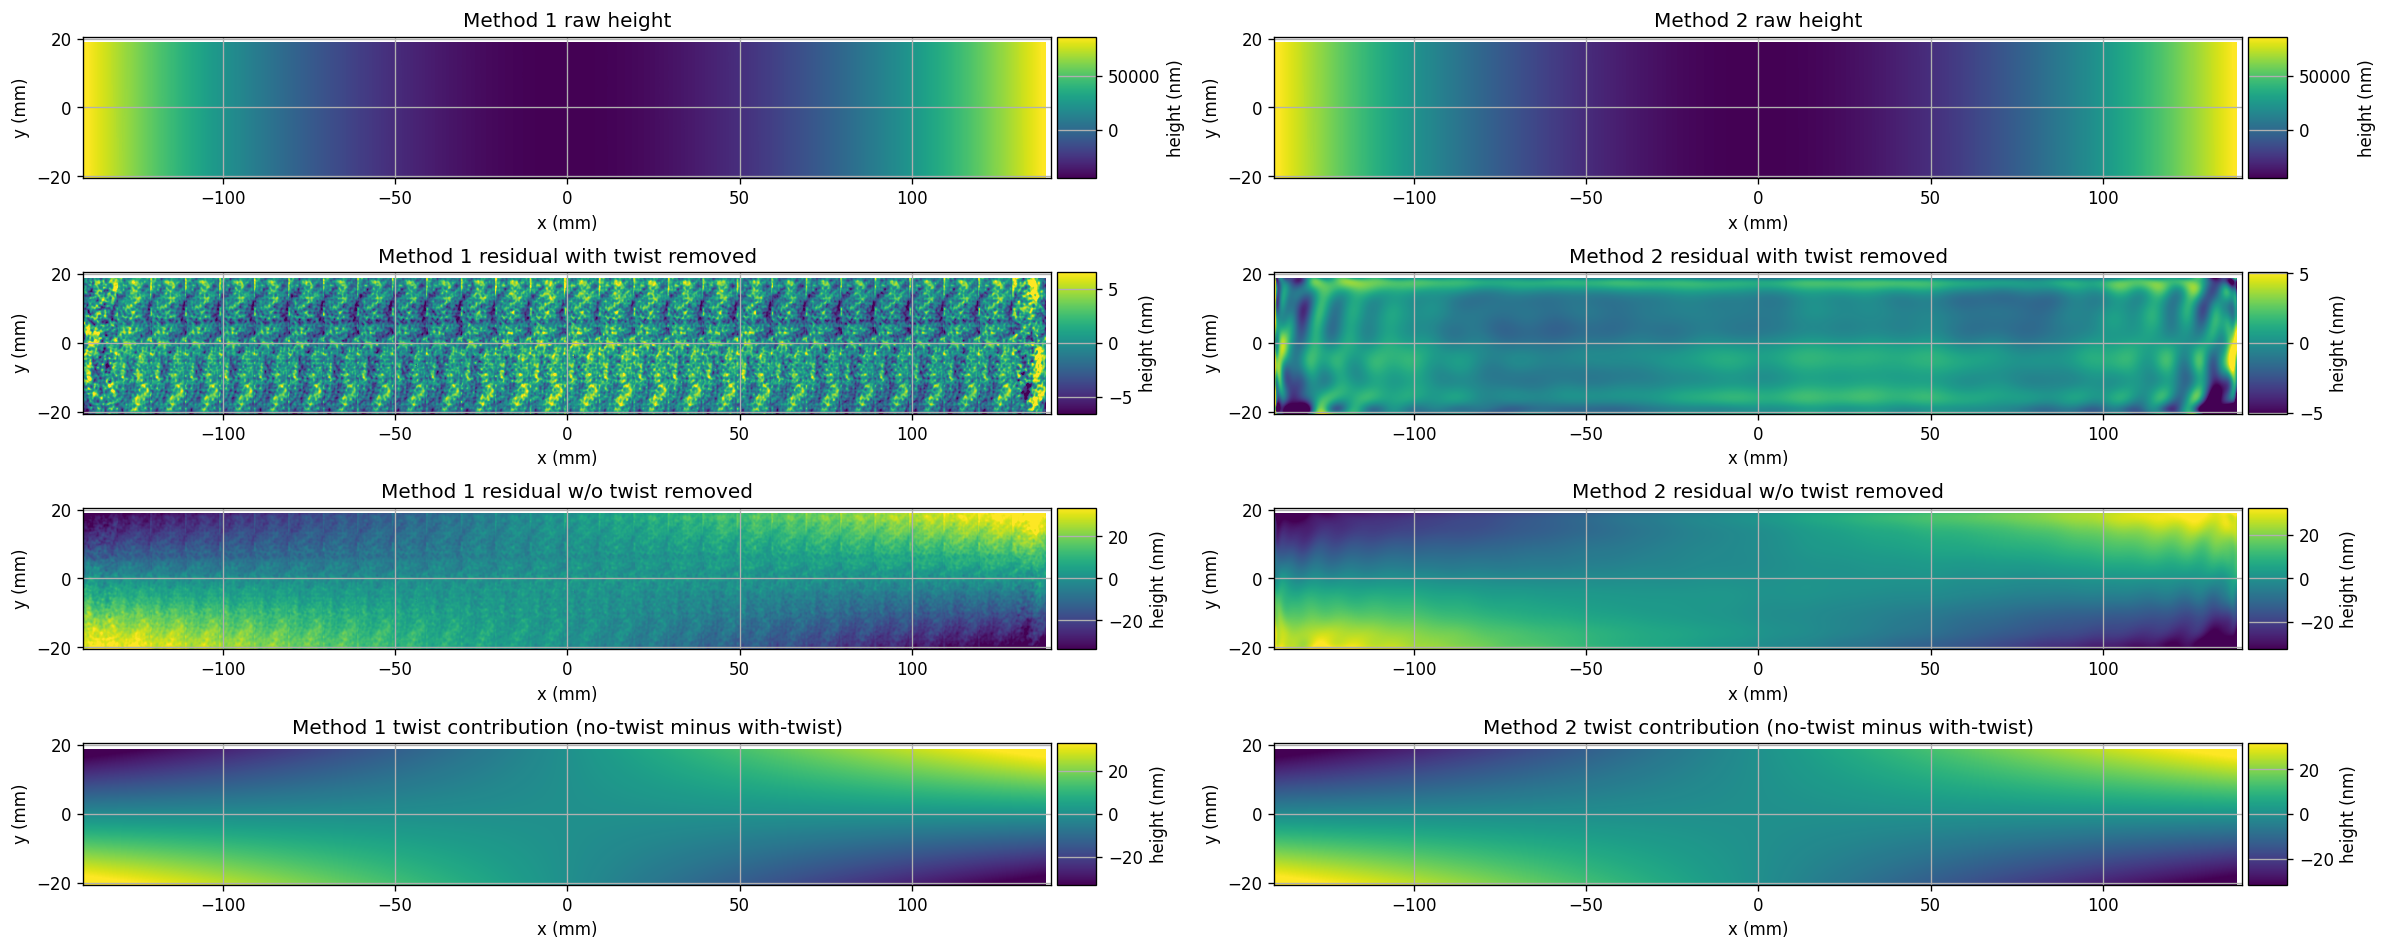

In [63]:
fig, axes = plt.subplots(4, 2, figsize=(20, 8), constrained_layout=False)
# for col, base, label in [(0, 'baseline', 'Sequential'), (1, 'adp', 'ADP')]:
for col, base, label in [(0, 'baseline', 'Method 1'), (1, 'adp', 'Method 2')]:
    ft = fits[(base, 'with_twist')]
    nt = fits[(base, 'no_twist')]
    ref = ft if ft is not None else nt
    raw = ref['raw'] if ref is not None else None
    y_mm, x_mm = axes_for_image(raw, ref) if raw is not None else (None, None)
    show_map(axes[0, col], raw, f'{label} raw height', x_mm=x_mm, y_mm=y_mm, symmetric=False)
    show_map(axes[1, col], ft['residual'] if ft is not None else None, f'{label} residual with twist removed', x_mm=ft['x_mm'] if ft is not None else None, y_mm=ft['y_mm'] if ft is not None else None)
    show_map(axes[2, col], nt['residual'] if nt is not None else None, f'{label} residual w/o twist removed', x_mm=nt['x_mm'] if nt is not None else None, y_mm=nt['y_mm'] if nt is not None else None)
    twist = (nt['residual'] - ft['residual']) if ft is not None and nt is not None else None
    show_map(axes[3, col], twist, f'{label} twist contribution (no-twist minus with-twist)', x_mm=ft['x_mm'] if ft is not None else None, y_mm=ft['y_mm'] if ft is not None else None)
plt.tight_layout()
plt.show()

## Long-Axis Height Profiles

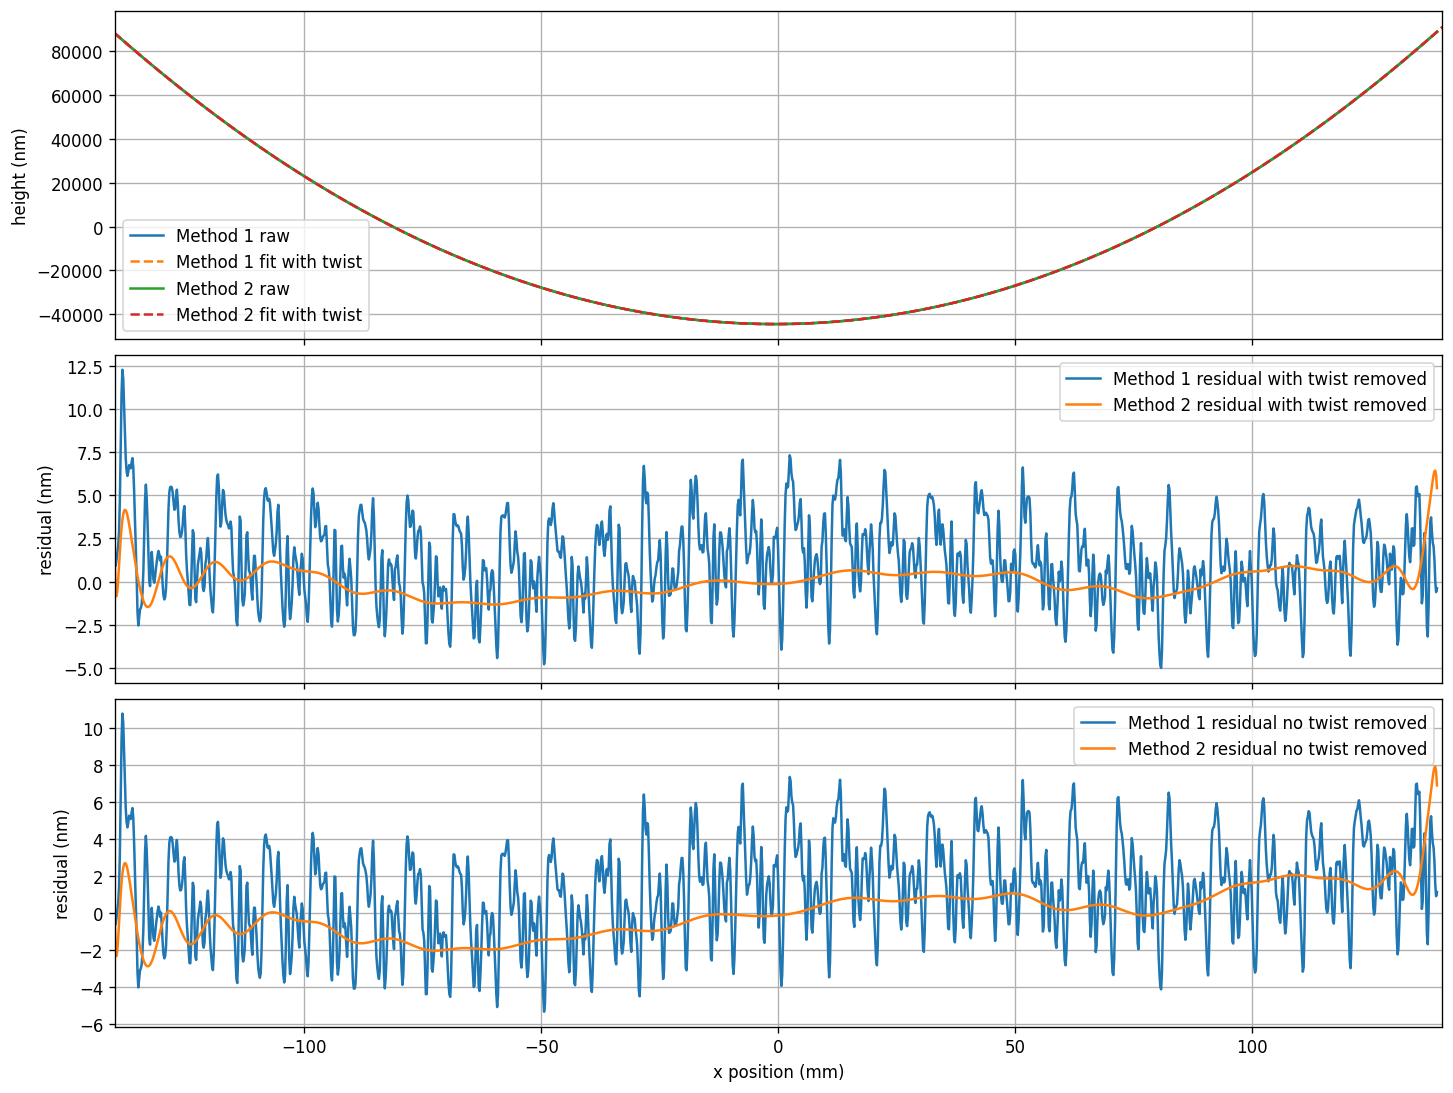

ValueError: '.o' is not a valid format string (two marker symbols)

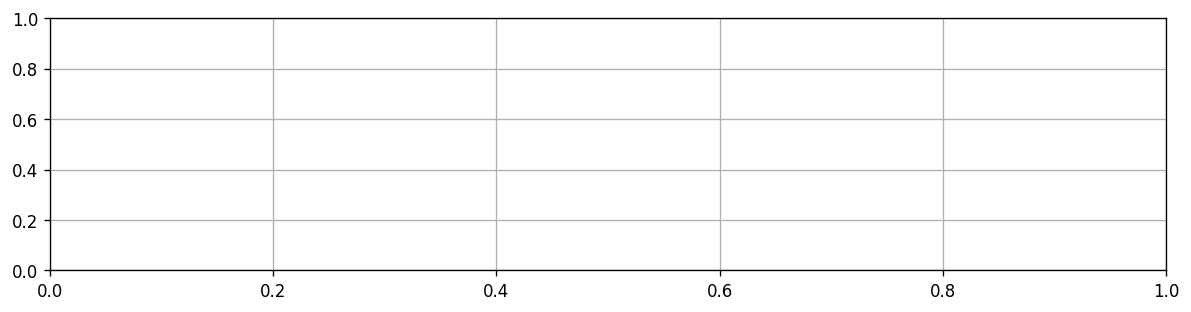

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
# for base, label in [('baseline', 'Sequential'), ('adp', 'ADP')]:
for base, label in [('baseline', 'Method 1'), ('adp', 'Method 2')]:
    ft = fits[(base, 'with_twist')]
    nt = fits[(base, 'no_twist')]
    if ft is None and nt is None:
        continue
    ref = ft if ft is not None else nt
    x = ref['x_mm']
    # raw_profile = nanmedian_profile(ref['raw'], axis=0)
    # axes[0].plot(x, raw_profile, label=f'{label} raw')
    
    # if ft is not None:
    #     axes[0].plot(x, nanmedian_profile(ft['fit'], axis=0), '--', label=f'{label} fit with twist')
    #     axes[1].plot(x, nanmedian_profile(ft['residual'], axis=0), label=f'{label} residual with twist removed')
    # if nt is not None:
    #     axes[2].plot(x, nanmedian_profile(nt['residual'], axis=0), label=f'{label} residual no twist removed')
    
    raw_profile = linecut_profile(ref['raw'], int(ref['raw'].shape[0]/2), axis=1)
    axes[0].plot(x, raw_profile, label=f'{label} raw')
    
    if ft is not None:
        axes[0].plot(x, linecut_profile(ft['fit'], int(ref['raw'].shape[0]/2), axis=1), '--', label=f'{label} fit with twist')
        axes[1].plot(x, linecut_profile(ft['residual'], int(ref['raw'].shape[0]/2), axis=1), label=f'{label} residual with twist removed')
    if nt is not None:
        axes[2].plot(x, linecut_profile(nt['residual'], int(ref['raw'].shape[0]/2), axis=1), label=f'{label} residual no twist removed')

axes[0].set_xlim([-140,140])
axes[1].set_xlim([-140,140])
axes[2].set_xlim([-140,140])
# axes[1].set_ylim([-2,2])
# axes[2].set_ylim([-10,10])
axes[0].set_ylabel('height (nm)')
axes[1].set_ylabel('residual (nm)')
axes[2].set_ylabel('residual (nm)')
axes[2].set_xlabel('x position (mm)')
for ax in axes:
    ax.legend()
plt.show()

import matplotlib.colors as mcolors
plt.figure(figsize=(12, 6))
plt.subplot(2,1, 1)
# linecut_md1 = fits[('baseline', 'with_twist')]['residual']
linecut_md2 = fits[('adp', 'with_twist')]['residual']
# plt.plot(x, linecut_profile(linecut_md1, int(linecut_md1.shape[0]/2), axis=1), label=f'Method1: residual with twist removed')
plt.plot(x, linecut_profile(linecut_md2, int(linecut_md2.shape[0]/2), axis=1), 'mcolors.CSS4_COLORS)
plt.show()')
plt.xlim([-130,130])
plt.ylim([-2,2])
plt.ylabel('residual (nm)')
plt.xlabel('x position (mm)')
plt.title('Residual comparison with twist removed')
plt.subplot(2,1, 2)
# linecut_md1 = fits[('baseline', 'no_twist')]['residual']
linecut_md2 = fits[('adp', 'no_twist')]['residual']
# plt.plot(x, linecut_profile(linecut_md1, int(linecut_md1.shape[0]/2), axis=1), label=f'Method1: residual w/o twist removed')
plt.plot(x, linecut_profile(linecut_md2, int(linecut_md2.shape[0]/2), axis=1), '.o', label=f'Method2: residual w/o twist removed')
plt.xlim([-130,130])
plt.ylim([-2,2])
plt.ylabel('residual (nm)')
plt.xlabel('x position (mm)')
plt.title('Residual comparison w/o twist removed')
plt.tight_layout()

print("RMS/PV summary: \nMethod1: {}".format(f"with twist: {finite_rms(linecut_profile(fits[('baseline', 'with_twist')]['residual'], int(fits[('baseline', 'with_twist')]['residual'].shape[0]/2), axis=1)):.6g}/{finite_pv(linecut_profile(fits[('baseline', 'with_twist')]['residual'], int(fits[('baseline', 'with_twist')]['residual'].shape[0]/2), axis=1)):.6g} nm, "
      f"no twist: {finite_rms(linecut_profile(fits[('baseline', 'no_twist')]['residual'], int(fits[('baseline', 'no_twist')]['residual'].shape[0]/2), axis=1)):.6g}/{finite_pv(linecut_profile(fits[('baseline', 'no_twist')]['residual'], int(fits[('baseline', 'no_twist')]['residual'].shape[0]/2), axis=1)):.6g} nm\n"
      "Method2: {}".format(f"with twist: {finite_rms(linecut_profile(fits[('adp', 'with_twist')]['residual'], int(fits[('adp', 'with_twist')]['residual'].shape[0]/2), axis=1)):.6g}/{finite_pv(linecut_profile(fits[('adp', 'with_twist')]['residual'], int(fits[('adp', 'with_twist')]['residual'].shape[0]/2), axis=1)):.6g} nm, "
      f"no twist: {finite_rms(linecut_profile(fits[('adp', 'no_twist')]['residual'], int(fits[('adp', 'no_twist')]['residual'].shape[0]/2), axis=1)):.6g}/{finite_pv(linecut_profile(fits[('adp', 'no_twist')]['residual'], int(fits[('adp', 'no_twist')]['residual'].shape[0]/2), axis=1)):.6g} nm")))

## ADP Vs Sequential Comparison

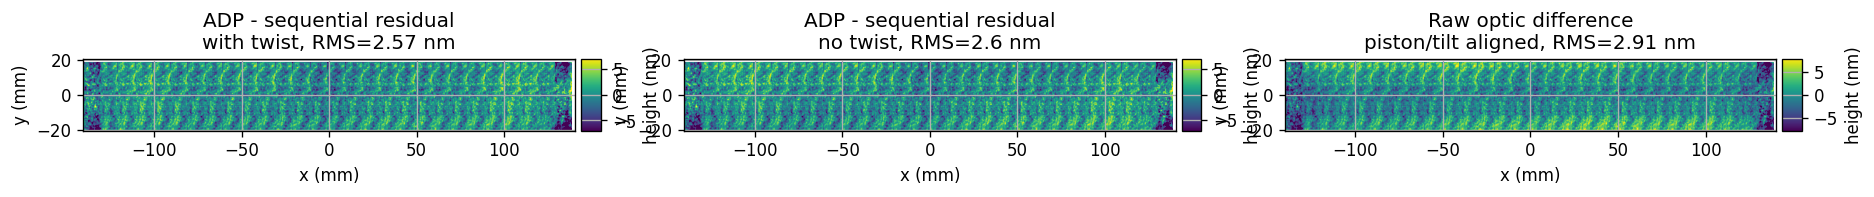

ADP minus sequential residual comparison
  with twist RMS/PV: 2.57295 / 71.7783 nm
  no twist RMS/PV: 2.60253 / 69.4427 nm
  raw aligned RMS/PV: 2.90636 / 69.4427 nm


In [53]:
seq_ft = fits[('baseline', 'with_twist')]
adp_ft = fits[('adp', 'with_twist')]
seq_nt = fits[('baseline', 'no_twist')]
adp_nt = fits[('adp', 'no_twist')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
with_twist_diff = adp_ft['residual'] - seq_ft['residual'] if adp_ft is not None and seq_ft is not None else arr('autodiff_minus_sequential_with_twist', arr('autodiff_minus_sequential'))
no_twist_diff = adp_nt['residual'] - seq_nt['residual'] if adp_nt is not None and seq_nt is not None else arr('autodiff_minus_sequential_no_twist')
raw_diff = arr('autodiff_minus_sequential_raw_aligned')
ref = adp_ft if adp_ft is not None else seq_ft
x_mm = ref['x_mm'] if ref is not None else None
y_mm = ref['y_mm'] if ref is not None else None
show_map(axes[0], with_twist_diff, f'ADP - sequential residual\nwith twist, RMS={finite_rms(with_twist_diff):.3g} nm', x_mm=x_mm, y_mm=y_mm)
show_map(axes[1], no_twist_diff, f'ADP - sequential residual\nno twist, RMS={finite_rms(no_twist_diff):.3g} nm', x_mm=x_mm, y_mm=y_mm)
show_map(axes[2], raw_diff, f'Raw optic difference\npiston/tilt aligned, RMS={finite_rms(raw_diff):.3g} nm', x_mm=x_mm, y_mm=y_mm)
plt.show()

print('ADP minus sequential residual comparison')
print(f"  with twist RMS/PV: {finite_rms(with_twist_diff):.6g} / {finite_pv(with_twist_diff):.6g} nm")
print(f"  no twist RMS/PV: {finite_rms(no_twist_diff):.6g} / {finite_pv(no_twist_diff):.6g} nm")
if raw_diff is not None:
    print(f"  raw aligned RMS/PV: {finite_rms(raw_diff):.6g} / {finite_pv(raw_diff):.6g} nm")

## Recovered Systematic Error And Reconstruction Residual

C:\Users\qiaoz\AppData\Local\Temp\ipykernel_46192\1782052073.py:11: RuntimeWarning: All-NaN slice encountered
  med_err = np.nanmedian(err, axis=0)


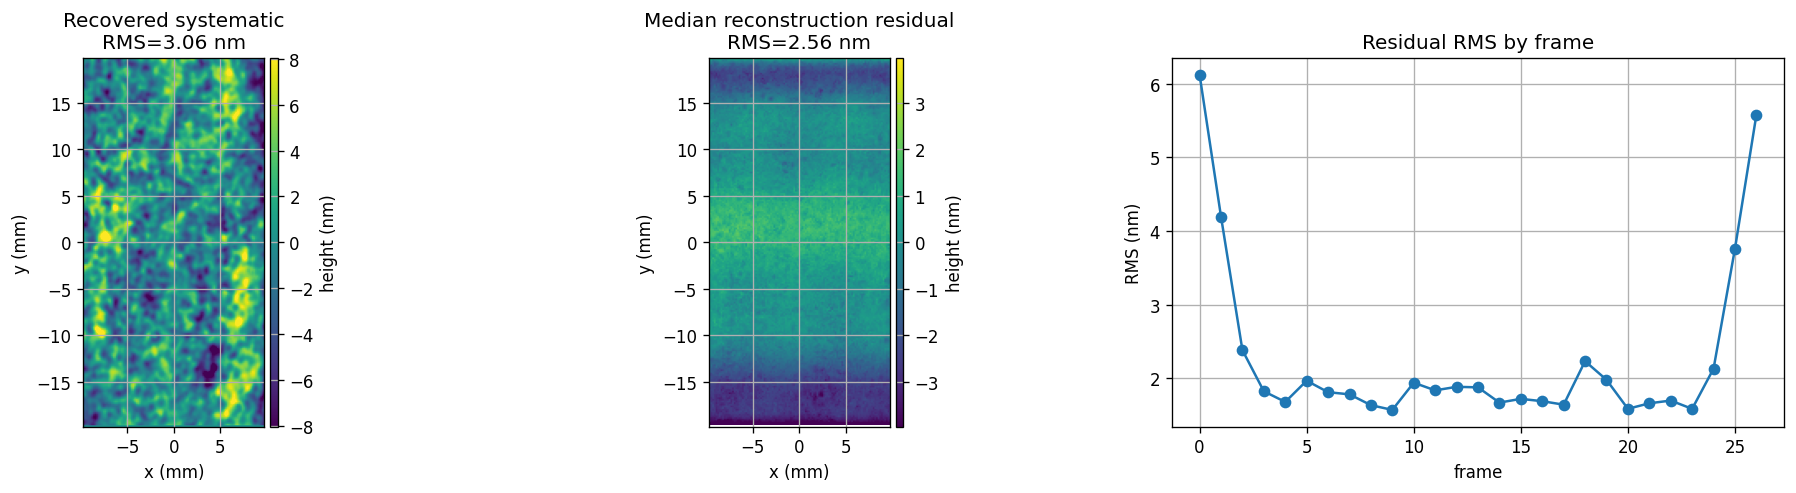

In [54]:
systematic = arr('recovered_systematic_error_nm', arr('systematic'))
err = arr('adp_reconstruction_error_nm', arr('reconstruction_error_nm'))

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
if systematic is not None and np.asarray(systematic).ndim == 2 and np.asarray(systematic).size:
    sy_mm, sx_mm = axes_for_image(systematic)
else:
    sy_mm, sx_mm = None, None
show_map(axes[0], systematic if systematic is not None and np.asarray(systematic).size else None, f'Recovered systematic\nRMS={finite_rms(systematic):.3g} nm', x_mm=sx_mm, y_mm=sy_mm)
if err is not None and np.asarray(err).ndim == 3 and np.asarray(err).size:
    med_err = np.nanmedian(err, axis=0)
    ey_mm, ex_mm = axes_for_image(med_err)
    show_map(axes[1], med_err, f'Median reconstruction residual\nRMS={finite_rms(err):.3g} nm', x_mm=ex_mm, y_mm=ey_mm)
    frame_rms = arr('adp_reconstruction_error_rms_by_frame_nm', arr('reconstruction_error_rms_by_frame_nm'))
    if frame_rms is not None and np.asarray(frame_rms).size:
        axes[2].plot(frame_rms, marker='o')
        axes[2].set_title('Residual RMS by frame')
        axes[2].set_xlabel('frame')
        axes[2].set_ylabel('RMS (nm)')
    else:
        axes[2].text(0.5, 0.5, 'No frame RMS saved', ha='center', va='center')
        axes[2].set_axis_off()
else:
    show_map(axes[1], None, 'Median reconstruction residual')
    axes[2].text(0.5, 0.5, 'No residual stack saved', ha='center', va='center')
    axes[2].set_axis_off()
# plt.tight_layout()
plt.show()

## Frame Browser

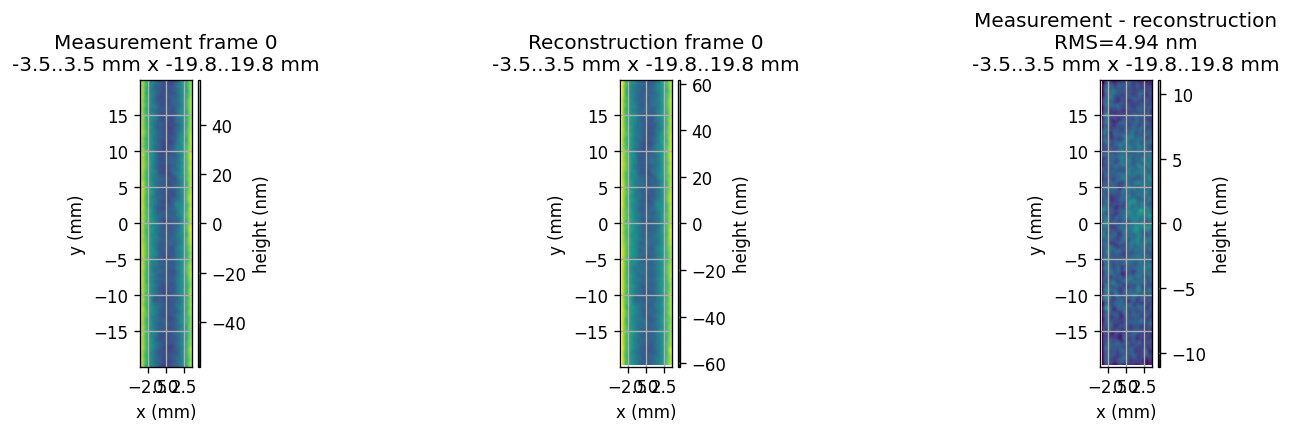

In [12]:
# Change frame_idx to inspect individual processed measurement, reconstruction, and residual.
frame_idx = 0
err = arr('adp_reconstruction_error_nm', arr('reconstruction_error_nm'))
recon = arr('adp_reconstructed_measurements_nm', arr('reconstructed_measurements_nm'))
meas = arr('input_measurements_nm')

if meas is not None and recon is not None and err is not None:
    frame_idx = int(np.clip(frame_idx, 0, np.asarray(meas).shape[0] - 1))
    fy_mm, fx_mm = axes_for_image(meas[frame_idx])
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
    show_map(axes[0], meas[frame_idx], f'Measurement frame {frame_idx}', x_mm=fx_mm, y_mm=fy_mm)
    show_map(axes[1], recon[frame_idx], f'Reconstruction frame {frame_idx}', x_mm=fx_mm, y_mm=fy_mm)
    show_map(axes[2], err[frame_idx], f'Measurement - reconstruction\nRMS={finite_rms(err[frame_idx]):.3g} nm', x_mm=fx_mm, y_mm=fy_mm)
    plt.show()
else:
    print('Frame browser needs input_measurements_nm, reconstructed_measurements_nm, and reconstruction_error_nm/adp_reconstruction_error_nm.')